In [4]:
from cone_sign_analysis import *

# --------------------------------------------------------------------------
# Worked examples from the paper
# --------------------------------------------------------------------------
if __name__ == "__main__":

    print("=" * 70)
    print("Example 1: cycle-matroid tree diagram (|F| = 2, expect 6 survivors)")
    print("=" * 70)
    # generators a_e^B for e1..e5 (rows), tau in R^2
    A_cycle = np.array([
        [-1, 0],   # e1
        [-1, 0],   # e2  (parallel to e1)
        [ 1, -1],   # e3
        [ 0,  1],   # e4
        [ 0,  1],   # e5  (parallel to e4)
    ]).T
    survivors = find_surviving_sign_vectors(A_cycle, verbose=True)
    print(f"\n{len(survivors)} surviving sign vectors:")
    for s in survivors:
        print("  ", format_sign_vector(s))

    print()
    print("=" * 70)
    print("Example 2: bond-matroid case (|F| = 3, expect 18 survivors)")
    print("=" * 70)
    # generators a_e^B for e1..e5 (rows), tau in R^3
    A_bond = np.array([
        [ 1,  1,  0],   # e1
        [-1,  0,  0],   # e2
        [ 0,  1,  0],   # e3
        [ 0,  1,  1],   # e4
        [ 0,  0, -1],   # e5
    ]).T
    survivors = find_surviving_sign_vectors(A_bond, verbose=True)
    print(f"\n{len(survivors)} surviving sign vectors:")
    for s in survivors:
        print("  ", format_sign_vector(s))

Example 1: cycle-matroid tree diagram (|F| = 2, expect 6 survivors)
2 edges reduce to 2 independent hyperplane direction(s).
Search space: 2^2 = 4  ->  2^2 = 4 LP calls.

4 surviving sign vectors:
   (+, +)
   (+, -)
   (-, +)
   (-, -)

Example 2: bond-matroid case (|F| = 3, expect 18 survivors)
3 edges reduce to 3 independent hyperplane direction(s).
Search space: 2^3 = 8  ->  2^3 = 8 LP calls.

8 surviving sign vectors:
   (+, +, +)
   (+, +, -)
   (+, -, +)
   (+, -, -)
   (-, +, +)
   (-, +, -)
   (-, -, +)
   (-, -, -)


  d = (1, 1, 1, 1)   q0 = (0, 0)
  --------------------------------------------------
     #     sigma           Q1        Q2  status
  --------------------------------------------------
     1                 -3.000     1.000  hull
     2                 -3.000    -1.000  hull
     3                  1.000    -3.000  hull
     4                 -1.000    -3.000  hull
     5                  1.000     3.000  hull
     6                 -1.000     3.000  hull
     7                  3.000     1.000  hull
     8                  3.000    -1.000  hull

  Hull: 8-gon   (8 of 8 sigma-points on hull)
  Predicted from directions: 8-gon  [matches]

  d = (1, 2, 3, 4)   q0 = (0, 0)
  --------------------------------------------------
     #     sigma           Q1        Q2  status
  --------------------------------------------------
     1                 -6.000     5.000  hull
     2                 -6.000    -3.000  hull
     3                  4.000    -7.000  hull
     4                 -2.

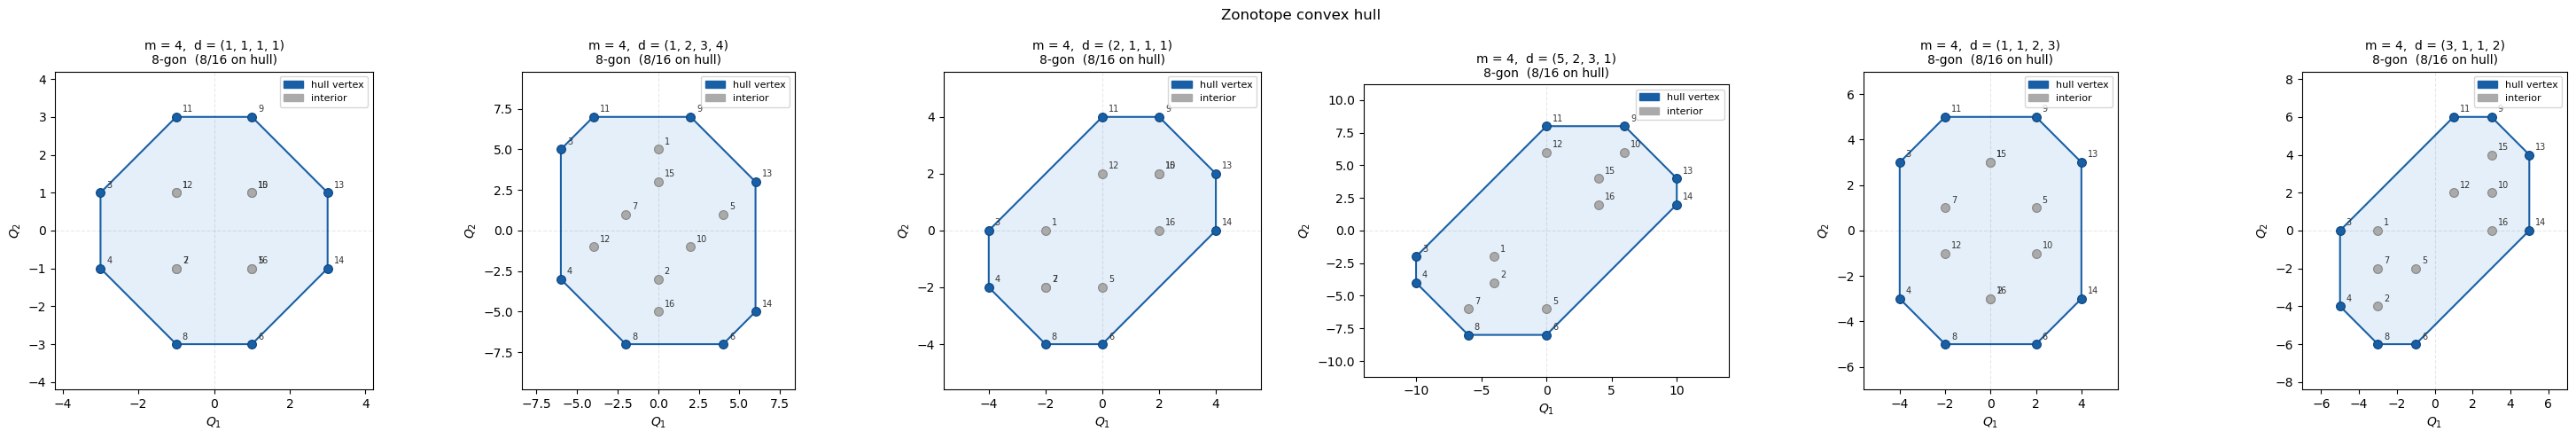

In [5]:
from zonotope_analysis import *

# ---------------------------------------------------------------------------
# Example Data (for the non-graphical matroid)
# ---------------------------------------------------------------------------

# exmaple surviving sign vectors
ORIENTATIONS = [
    ("1", [+1, +1, -1, +1]),
    ("2", [+1, +1, -1, -1]),
    ("3", [+1, -1, +1, -1]),
    ("4", [+1, -1, -1, -1]),
    ("5", [-1, +1, +1, +1]),
    ("6", [-1, +1, -1, +1]),
    ("7", [-1, -1, +1, +1]),
    ("8", [-1, -1, +1, -1]),
]

# If you want to pass a specific example from the previous block use:
# ORIENTATIONS = [(str(i+1), np.array(s)) for i, s in enumerate(survivors)]


# Columns of the generator matrix  (each row is a_e^B)
DIRS = np.array([
    [-1, -1],   # a_1^B
    [-1, +1],   # a_2^B
    [+1,  0],   # a_3^B
    [ 0, +1],   # a_4^B
], dtype=float)

# Each row is a d-vector, q^sigma = q_0 + \sum \sigma_e * d_e * a_e^B
# Change the d-vector to see how the zonotope shape changes
demo_cases = [[1, 1, 1, 1],
            [1, 2, 3, 4],
            [2, 1, 1, 1],
            [5, 2, 3, 1],
            [1, 1, 2, 3],
            [3, 1, 1, 2]]

# Check if d-vector dim == sigma-vector dim
if len(demo_cases[0]) != len(ORIENTATIONS[0][1]):
    raise ValueError(f"The d-vector dim ({len(demo_cases[0])}) does not match sigma-vector dim ({len(ORIENTATIONS[0][1])}).")

zs = [Zonotope(DIRS, d=d) for d in demo_cases]
for z_i in zs:
    print_table(z_i, orientations=ORIENTATIONS)  # if orientations=None, all possible sign vectors are plotted 
                                                 # many of which are simply empty

fig = plot(zs)
#out_path = "zonotope_hulls.png"
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"Plot saved to {out_path}")
plt.show()
    

  Primal hull: 8-gon,  dual: 8 vertices
       primal vertex               dual vertex         
  ------------------------------------------------------
     (  3.000,   1.000)      ( -0.333333,  -0.000000)  
     (  1.000,   3.000)      ( -0.250000,  -0.250000)  
     ( -1.000,   3.000)      (  0.000000,  -0.333333)  
     ( -3.000,   1.000)      (  0.250000,  -0.250000)  
     ( -3.000,  -1.000)      (  0.333333,   0.000000)  
     ( -1.000,  -3.000)      (  0.250000,   0.250000)  
     (  1.000,  -3.000)      ( -0.000000,   0.333333)  
     (  3.000,  -1.000)      ( -0.250000,   0.250000)  

  Vol(P)  = 28.000000
  Vol(P*) = 0.333333
  2! * Vol(P*) = 0.666667   (companion-paper normalisation |F|! Vol)

  Primal hull: 8-gon,  dual: 8 vertices
       primal vertex               dual vertex         
  ------------------------------------------------------
     ( -6.000,   5.000)      ( -0.166667,  -0.000000)  
     ( -6.000,  -3.000)      ( -0.111111,  -0.111111)  
     ( -2.000,  -7.0

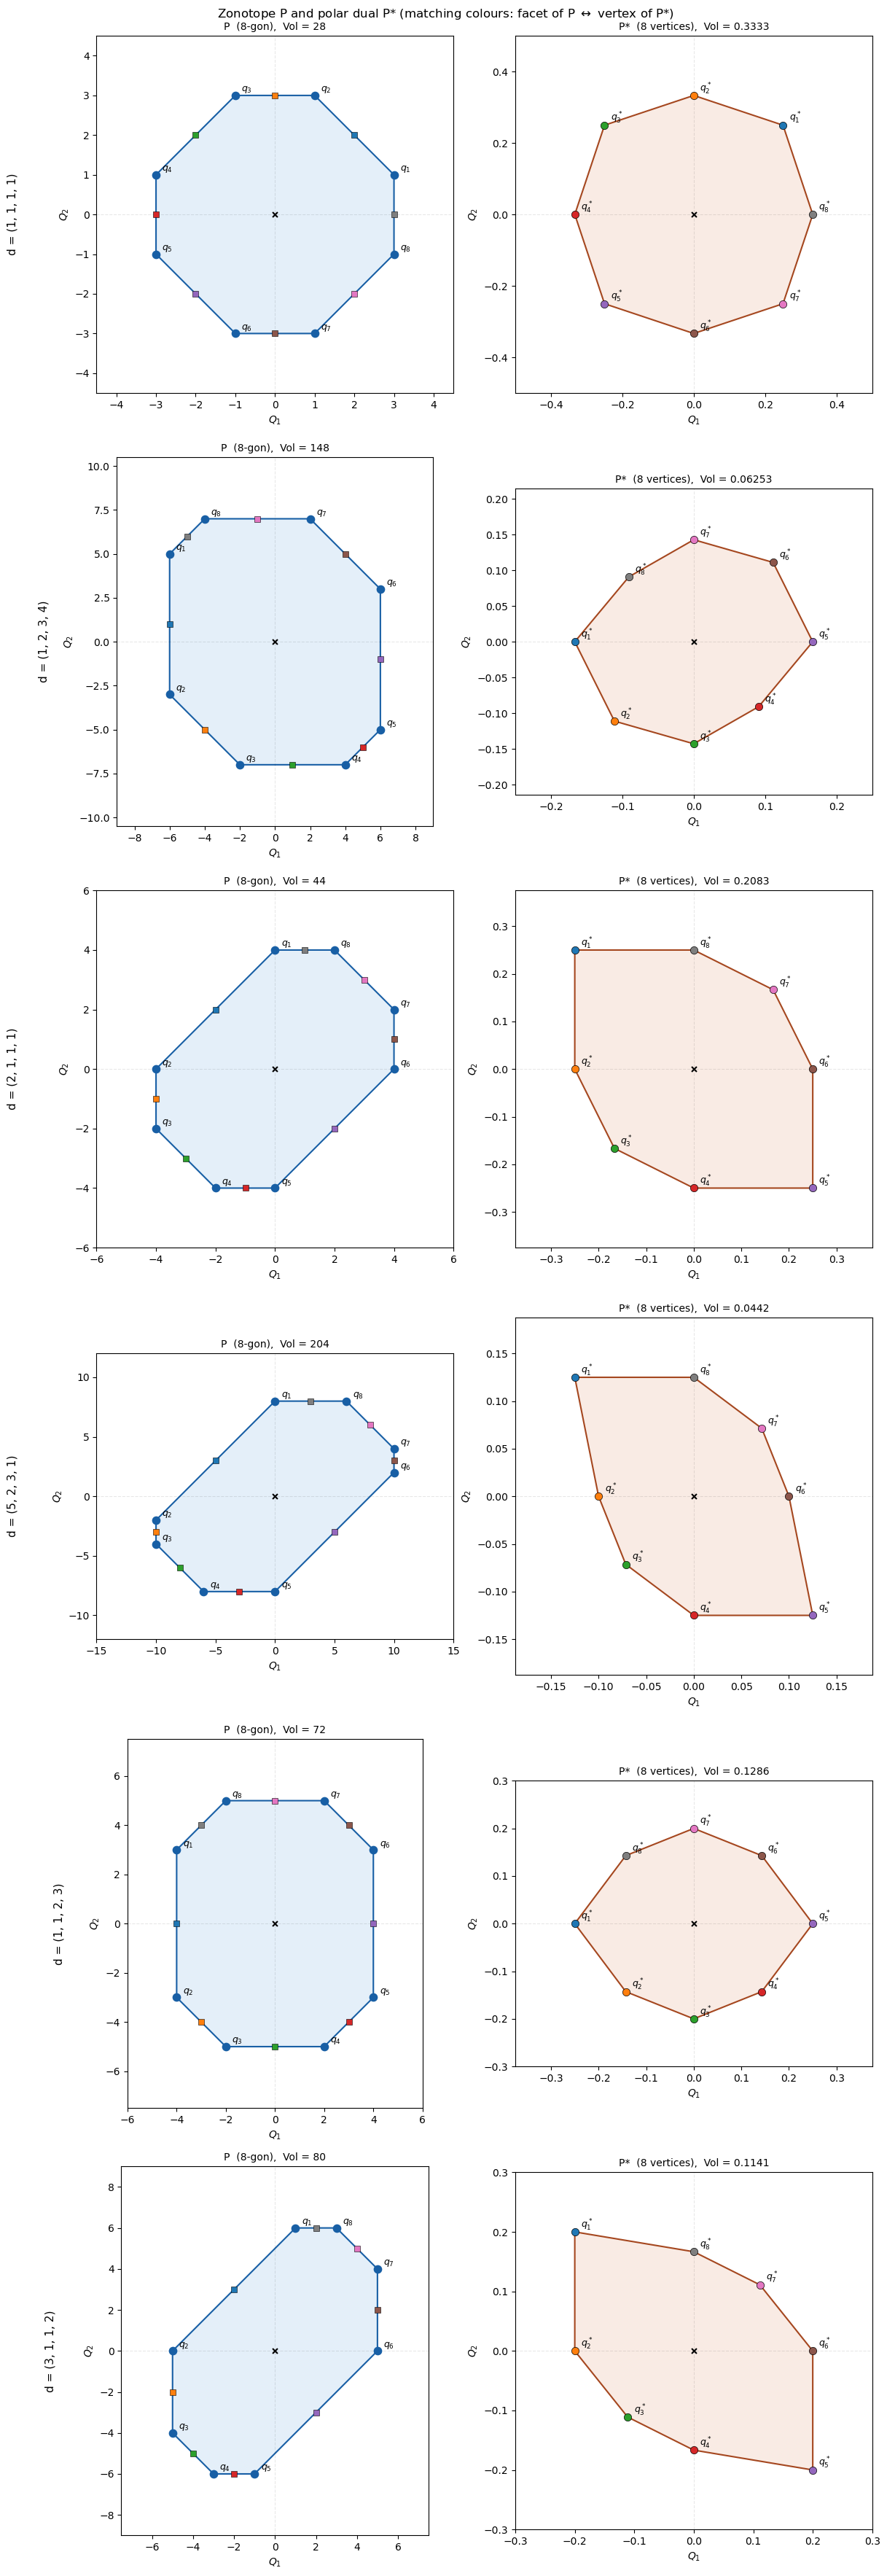

In [6]:
from dual_analysis import *

# ---------------------------------------------------------------------------
# Polar Dual  (uses the module-level ORIENTATIONS / DIRS of the zonotope code)
# ---------------------------------------------------------------------------

# sweep over the same d cases as the primal demo
demo_cases = [[1, 1, 1, 1],
                [1, 2, 3, 4],
                [2, 1, 1, 1],
                [5, 2, 3, 1],
                [1, 1, 2, 3],
                [3, 1, 1, 2]]
zs = [Zonotope(DIRS, d=d) for d in demo_cases]
for z_i in zs:
    print_dual_table(z_i, orientations=ORIENTATIONS, factorial_dim=2)

fig = plot_primal_dual(zs, orientations=ORIENTATIONS,
                        titles=[f"d = {tuple(d)}" for d in demo_cases])
#out_path = "zonotope_duals.png"
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"Plot saved to {out_path}")
plt.show()

In [7]:
# force-reload (to avoid using old cached version)
import importlib, cone_sign_analysis
importlib.reload(cone_sign_analysis)
from cone_sign_analysis import find_surviving_sign_vectors


5 edges reduce to 5 independent hyperplane direction(s).
Search space: 2^5 = 32  ->  2^5 = 32 LP calls.

18 surviving sign vectors
  d = (1, 1, 1, 1, 1)   q0 = (0, 0, 0)
  --------------------------------------------------
     #      sigma            Q1        Q2        Q3  status
  --------------------------------------------------
     1                    0.000     3.000     0.000  hull
     2                    0.000     3.000     2.000  hull
     3                    0.000     1.000    -2.000  hull
     4                    2.000     3.000     0.000  hull
     5                    2.000     3.000     2.000  hull
     6                    2.000     1.000    -2.000  hull
     7                    2.000     1.000     2.000  hull
     8                    2.000    -1.000    -2.000  hull
     9                    2.000    -1.000     0.000  hull
    10                   -2.000     1.000     0.000  hull
    11                   -2.000     1.000     2.000  hull
    12                   -

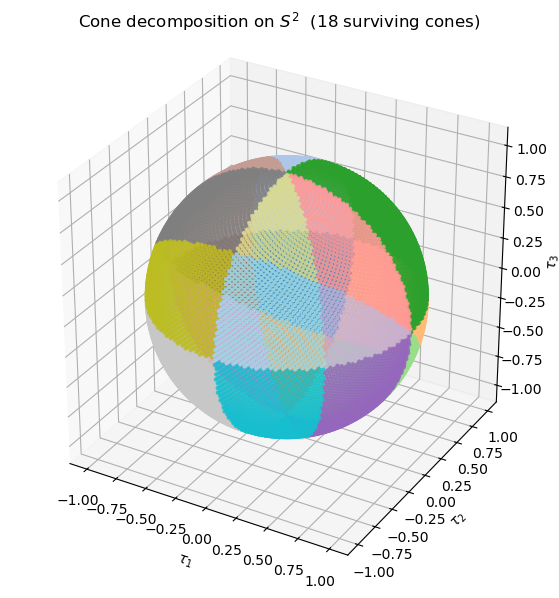

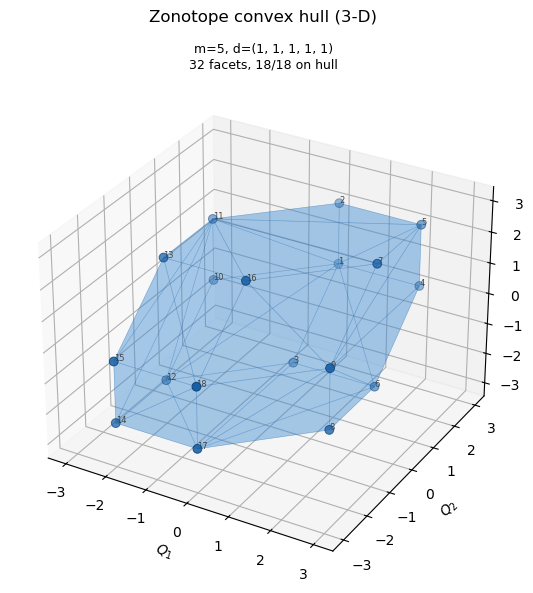

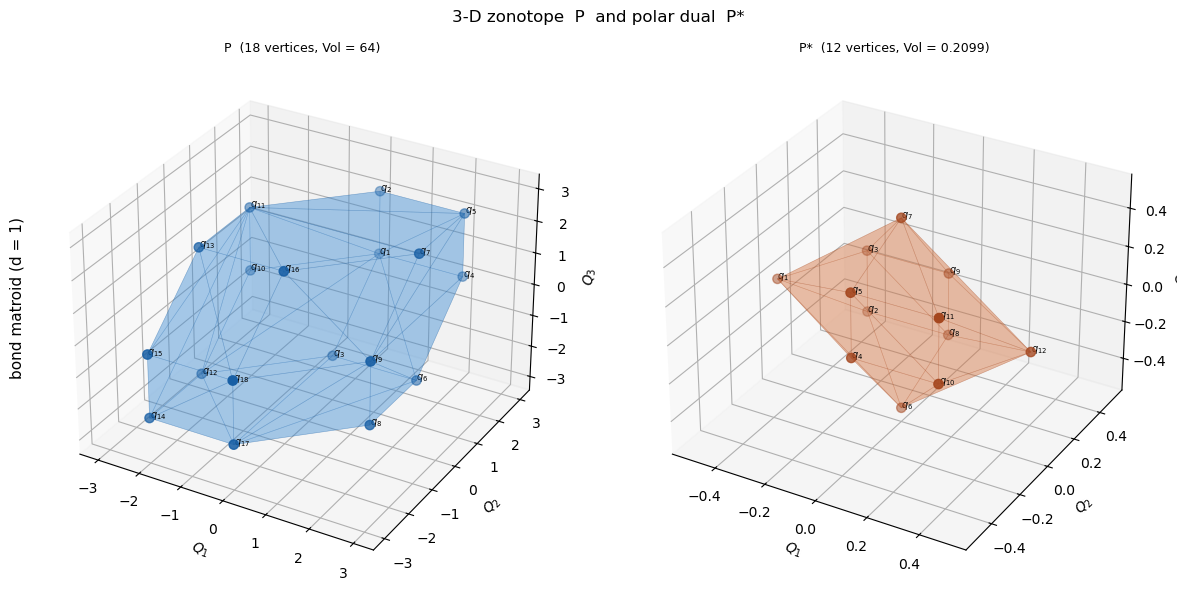

In [8]:
from full_generic_analysis import *
from zonotope_analysis import *

# ---------------------------------------------------------------------------
# Bond-matroid (Example 2) full pipeline - 3D plotting
# ---------------------------------------------------------------------------

A_bond = np.array([
    [ 1,  1,  0],   # e1
    [-1,  0,  0],   # e2
    [ 0,  1,  0],   # e3
    [ 0,  1,  1],   # e4
    [ 0,  0, -1],   # e5
], dtype=float)

survivors_bond = find_surviving_sign_vectors(A_bond, verbose=True)
bond_orients   = [(str(i + 1), np.array(s, dtype=float))
                    for i, s in enumerate(survivors_bond)]
print(f'\n{len(survivors_bond)} surviving sign vectors')

z_bond = Zonotope(A_bond)    # generators = rows of A_bond, d_e = 1 for all e

print_table(z_bond, orientations=bond_orients)

# -- cone decomposition on S^2 -----------------------------------------
fig_c = plot_cone_decomposition(A_bond, survivors_bond, n_pts=16000)
#fig_c.savefig('bond_cone_decomp.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 3-D zonotope convex hull ------------------------------------------
fig_z = plot_3d(z_bond, orientations=bond_orients)
#fig_z.savefig('bond_zonotope_3d.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 3-D primal P and polar dual P* ------------------------------------
fig_pd = plot_primal_dual_3d(z_bond, orientations=bond_orients,
                                titles=['bond matroid (d = 1)'])
#fig_pd.savefig('bond_primal_dual_3d.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# ---------------------------------------------------------------------------
# Bond-matroid (Example 2) full pipeline - 3D plotting
# ---------------------------------------------------------------------------

# force-reload (to avoid using old cached version)
import importlib, cone_sign_analysis
importlib.reload(cone_sign_analysis)
from cone_sign_analysis import find_surviving_sign_vectors

import numpy as np
from cone_sign_analysis import find_surviving_sign_vectors
from interactive_3d_plots import *

# shape = (n_edges, n_constraints)
A_bond = np.array([
    [ 1,  1,  0],
    [-1,  0,  0],
    [ 0,  1,  0],
    [ 0,  1,  1],
    [ 0,  0, -1],
], dtype=float)

survivors_bond = find_surviving_sign_vectors(A_bond)
bond_orients   = [(str(i + 1), np.array(s, dtype=float))
                  for i, s in enumerate(survivors_bond)]
z_bond = Zonotope(A_bond)

# 1) Cone decomposition on S²
fig_c = plot_cone_decomposition_interactive(A_bond, survivors_bond)
fig_c.show()

# 2) Zonotope convex hull
fig_z = plot_3d_interactive(z_bond, orientations=bond_orients)
fig_z.show()

# 3) Primal P and polar dual P*
fig_pd = plot_primal_dual_3d_interactive(z_bond, orientations=bond_orients,
                                          titles=['bond matroid (d = 1)'])
fig_pd.show()


In [10]:
# ---------------------------------------------------------------------------
# Two loop box diagram: full pipeline - 3D plotting
# ---------------------------------------------------------------------------

# force-reload (to avoid using old cached version)
import importlib, cone_sign_analysis
importlib.reload(cone_sign_analysis)
from cone_sign_analysis import find_surviving_sign_vectors

import numpy as np
from cone_sign_analysis import find_surviving_sign_vectors
from interactive_4d_plots import *
from zonotope_analysis import print_table

# shape = (n_edges, n_constraints)
A_box2 = np.array([
    [1, 0, 0, 0],
    [0, -1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, -1],
    [-1, 1, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 1, 1],
    [-1, 0, 0, 1]
], dtype=float)

survivors_box2 = find_surviving_sign_vectors(A_box2)
box2_orients   = [(str(i + 1), np.array(s, dtype=float))
                  for i, s in enumerate(survivors_box2)]
z_box2 = Zonotope(A_box2)


# 1) Cone decomposition on S²
fig_c = plot_cone_decomposition_interactive_4d(A_box2, survivors_box2)
fig_c.show()

# 2) Zonotope convex hull
fig_z = plot_4d_interactive(z_box2, orientations=box2_orients)
fig_z.show()

# 3) Primal P and polar dual P*
fig_pd = plot_primal_dual_4d_interactive(z_box2, orientations=box2_orients,
                                            titles=['(d = 1)'])
fig_pd.show()

# check for simpliciality
from cone_checker import *
scan_matrix(A_box2, verbose=True, basis=[0,1,2,3])


Pre-screen: every basis submatrix has |det|=1 (matrix is totally unimodular) -> all cones will be simplicial.
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, 1, 1, 1, -1, 1, 1, 1, -1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, 1, -1, -1, -1, -1, -1, 1, 1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, 1, -1, -1, 1, 1, 1, -1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, -1, 1, 1, 1, 1, -1, -1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, -1, -1, 1, 1, 1, 1, 1), facets=6, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, -1, -1, 1, 1, 1, -1, -1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, -1, -1, 1, -1, -1, -1, 1), facets=5, rays=5, dim=4
NON-SIMPLICIAL: basis=(0, 1, 2, 3), det(A_B)=1, sigma=(1, -1, -1, -1, -1, 1, 1, 1, -1), facets=5, rays=5, dim=4


[{'basis': (0, 1, 2, 3),
  'sigma': (1, 1, 1, 1, -1, 1, 1, 1, -1),
  'det_AB': np.float64(1.0),
  'status': 'non_simplicial',
  'n_facets': 5,
  'n_rays': 5,
  'consistent': None,
  'margin': 0.5},
 {'basis': (0, 1, 2, 3),
  'sigma': (1, 1, 1, 1, -1, 1, 1, -1, -1),
  'det_AB': np.float64(1.0),
  'status': 'simplicial',
  'n_facets': 4,
  'n_rays': 4,
  'consistent': None,
  'margin': 0.3333333333333333},
 {'basis': (0, 1, 2, 3),
  'sigma': (1, 1, 1, 1, -1, -1, -1, 1, -1),
  'det_AB': np.float64(1.0),
  'status': 'simplicial',
  'n_facets': 4,
  'n_rays': 4,
  'consistent': None,
  'margin': 0.3333333333333333},
 {'basis': (0, 1, 2, 3),
  'sigma': (1, 1, 1, 1, -1, -1, -1, -1, -1),
  'det_AB': np.float64(1.0),
  'status': 'simplicial',
  'n_facets': 4,
  'n_rays': 4,
  'consistent': None,
  'margin': 0.5},
 {'basis': (0, 1, 2, 3),
  'sigma': (1, 1, 1, -1, -1, 1, 1, 1, 1),
  'det_AB': np.float64(1.0),
  'status': 'simplicial',
  'n_facets': 4,
  'n_rays': 4,
  'consistent': None,
  'margi